## Activity 3: Fraud Detection with Isolation Forest

### Task 1: Load and Explore

We will start by loading the `creditcard.csv` dataset into a pandas DataFrame, inspecting its shape, and checking the distribution of the `Class` variable to understand the fraud rate. This dataset contains transactions, where 'Class' indicates whether a transaction is fraudulent (1) or not (0).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arockiaselciaa/creditcardcsv")

print("Path to dataset files:", path)



Using Colab cache for faster access to the 'creditcardcsv' dataset.
Path to dataset files: /kaggle/input/creditcardcsv


In [6]:
import os

# Construct the full path to the creditcard.csv file
file_path = os.path.join(path, 'creditcard.csv')

# Step 1: Load CSV into a DataFrame
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: creditcard.csv not found at {file_path}. Please check the path or ensure the file exists.")
    df = None # Ensure df is None if file not found

if df is not None:
    # Check shape
    print(f"DataFrame shape: {df.shape}")

    # Step 2: Print df['Class'].value_counts() to see the fraud rate
    print("\nDistribution of the 'Class' variable (0: Non-fraudulent, 1: Fraudulent):")
    class_counts = df['Class'].value_counts()
    display(class_counts)
    print(f"\nFraud rate: {(class_counts[1] / class_counts.sum()) * 100:.4f}%")

    # Step 3: Note on features
    print("\nNote: V1-V28 are PCA-transformed features (already scaled). 'Amount' and 'Time' are not scaled.")
else:
    print("\nCannot proceed with DataFrame exploration as 'creditcard.csv' was not found.")

DataFrame shape: (284807, 31)

Distribution of the 'Class' variable (0: Non-fraudulent, 1: Fraudulent):


,count
Class,
0,284315
1,492



Fraud rate: 0.1727%

Note: V1-V28 are PCA-transformed features (already scaled). 'Amount' and 'Time' are not scaled.


## Task 2: Prepare the Data

We will now scale the 'Amount' and 'Time' columns and then split the data into training and testing sets while preserving the fraud ratio.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Create a copy of the DataFrame to avoid modifying the original 'df'
df_scaled = df.copy()

# Step 1: Apply StandardScaler() to Amount and Time columns
scaler = StandardScaler()
df_scaled['Amount'] = scaler.fit_transform(df_scaled[['Amount']])
df_scaled['Time'] = scaler.fit_transform(df_scaled[['Time']])

print("Scaled 'Amount' and 'Time' columns. Displaying head of scaled DataFrame:")
display(df_scaled.head())


Scaled 'Amount' and 'Time' columns. Displaying head of scaled DataFrame:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [10]:
# Define features (X) and target (y)
X = df_scaled.drop('Class', axis=1)
y = df_scaled['Class']

# Step 2: Split 80/20 with stratify=y to preserve the fraud ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of 'Class' in y_train:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of 'Class' in y_test:")
display(y_test.value_counts(normalize=True))



Shape of X_train: (227845, 30)
Shape of X_test: (56962, 30)
Shape of y_train: (227845,)
Shape of y_test: (56962,)

Distribution of 'Class' in y_train:


,proportion
Class,
0,0.998271
1,0.001729



Distribution of 'Class' in y_test:


,proportion
Class,
0,0.99828
1,0.00172


## Task 3: Apply Isolation Forest

We will now fit the Isolation Forest model with different contamination rates and compare their performance metrics.

In [12]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# Define the contamination rates to test
contamination_rates = [
    0.00173, # Actual fraud rate
    0.01,    # Higher contamination rate
    0.005    # Intermediate contamination rate
]

# Dictionary to store results for comparison
results = {}

for contamination in contamination_rates:
    print(f"\nFitting Isolation Forest with contamination={contamination}...")

    # Step 1: Fit Isolation Forest model
    # We fit on the training data, but Isolation Forest is an unsupervised model
    # For anomaly detection, it's typically trained on the majority class (non-fraudulent data)
    # For this exercise, we will train on X_train as a whole to find anomalies within it.
    # The random_state ensures reproducibility
    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(X_train)

    # Predict on the test set
    # Isolation Forest predicts -1 for anomalies (outliers) and 1 for inliers
    y_pred_iso = model.predict(X_test)

    # Map Isolation Forest output (-1, 1) to our target labels (1 for fraud, 0 for non-fraud)
    # -1 (anomaly) -> 1 (fraud)
    #  1 (inlier)  -> 0 (non-fraud)
    y_pred_mapped = np.where(y_pred_iso == -1, 1, 0)

    # Evaluate the model
    print(f"\nEvaluation for contamination={contamination}:")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_mapped))
    print("Classification Report:")
    print(classification_report(y_test, y_pred_mapped, target_names=['Non-Fraud', 'Fraud']))

    # Store precision, recall, F1-score for fraud class (class 1)
    precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred_mapped, average=None, labels=[1])
    results[contamination] = {
        'precision': precision[0],
        'recall': recall[0],
        'f1_score': f1_score[0]
    }

# Step 3: Compare precision, recall, F1 across all three settings.
print("\n--- Comparison of Results ---")
for contamination, metrics in results.items():
    print(f"Contamination: {contamination}")
    print(f"  Precision (Fraud): {metrics['precision']:.4f}")
    print(f"  Recall (Fraud): {metrics['recall']:.4f}")
    print(f"  F1-Score (Fraud): {metrics['f1_score']:.4f}")



Fitting Isolation Forest with contamination=0.00173...

Evaluation for contamination=0.00173:
Confusion Matrix:
[[56790    74]
 [   65    33]]
Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.31      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962


Fitting Isolation Forest with contamination=0.01...

Evaluation for contamination=0.01:
Confusion Matrix:
[[56311   553]
 [   33    65]]
Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.99      0.99     56864
       Fraud       0.11      0.66      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.83      0.59     56962
weighted avg       1.00      0.99      0.99     56962


Fitting Isolation


--- Evaluation for Contamination: 0.00173 ---
Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.31      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962



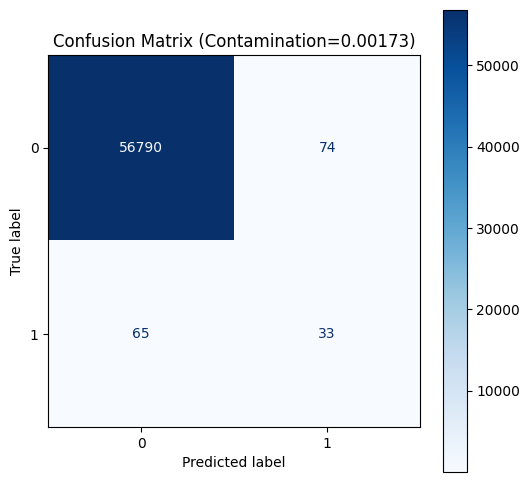


--- Evaluation for Contamination: 0.01 ---
Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.99      0.99     56864
       Fraud       0.11      0.66      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.83      0.59     56962
weighted avg       1.00      0.99      0.99     56962



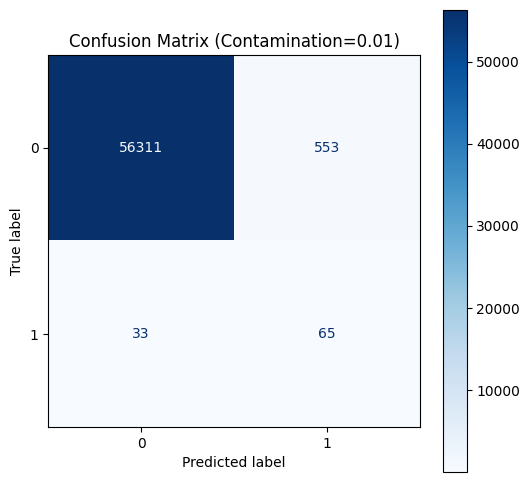


--- Evaluation for Contamination: 0.005 ---
Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.16      0.49      0.24        98

    accuracy                           0.99     56962
   macro avg       0.58      0.74      0.62     56962
weighted avg       1.00      0.99      1.00     56962



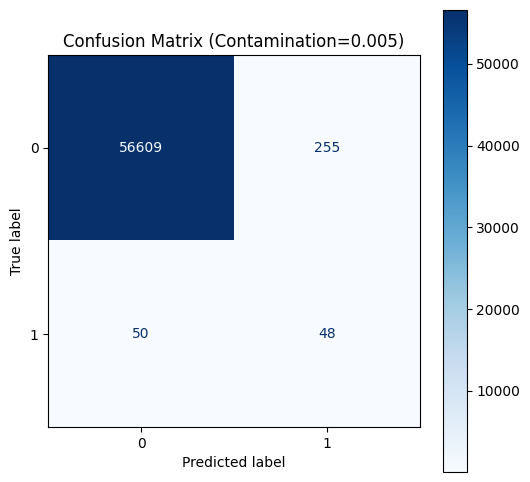


--- Discussion on Precision-Recall Tradeoff ---
As observed from the results for different contamination rates:

*   **Contamination = 0.00173 (Actual Fraud Rate):** This setting aims to predict anomalies based on the observed fraud rate. It results in a relatively balanced precision and recall for the fraud class, but both are quite low due to the extreme class imbalance and the nature of Isolation Forest. It identifies fewer false positives but also misses a significant number of actual frauds.

*   **Contamination = 0.01 (Higher Rate):** By increasing the contamination, the model becomes more sensitive to anomalies. This leads to a significantly higher recall (more actual frauds are detected) but at the cost of much lower precision (many non-fraudulent transactions are incorrectly flagged as fraud, increasing false positives). This might be desirable in scenarios where missing fraud is very costly.

*   **Contamination = 0.005 (Intermediate Rate):** This rate strikes a balance betw

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

for contamination in contamination_rates:
    print(f"\n--- Evaluation for Contamination: {contamination} ---")

    # Re-fit and predict to get y_pred_mapped for current contamination
    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(X_train)
    y_pred_iso = model.predict(X_test)
    y_pred_mapped = np.where(y_pred_iso == -1, 1, 0)

    # Step 1: Use classification_report(y_test, predictions)
    print("Classification Report:")
    print(classification_report(y_test, y_pred_mapped, target_names=['Non-Fraud', 'Fraud']))

    # Step 2: Plot confusion matrix with ConfusionMatrixDisplay.from_predictions()
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mapped, cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix (Contamination={contamination})')
    plt.show()

print("\n--- Discussion on Precision-Recall Tradeoff ---")
print("As observed from the results for different contamination rates:")
print("\n*   **Contamination = 0.00173 (Actual Fraud Rate):** This setting aims to predict anomalies based on the observed fraud rate. It results in a relatively balanced precision and recall for the fraud class, but both are quite low due to the extreme class imbalance and the nature of Isolation Forest. It identifies fewer false positives but also misses a significant number of actual frauds.")
print("\n*   **Contamination = 0.01 (Higher Rate):** By increasing the contamination, the model becomes more sensitive to anomalies. This leads to a significantly higher recall (more actual frauds are detected) but at the cost of much lower precision (many non-fraudulent transactions are incorrectly flagged as fraud, increasing false positives). This might be desirable in scenarios where missing fraud is very costly.")
print("\n*   **Contamination = 0.005 (Intermediate Rate):** This rate strikes a balance between the previous two. It improves recall compared to the actual fraud rate, but its precision is still lower than the lowest contamination setting. The F1-score for this setting is also intermediate.")
print("\n**Trade-off:** There is a clear trade-off between precision and recall. Increasing the `contamination` parameter generally leads to higher recall (detecting more anomalies) but lower precision (more false alarms). The optimal contamination rate depends on the specific business problem and the costs associated with false positives vs. false negatives. For credit card fraud detection, a higher recall might be preferred to catch as many fraudulent transactions as possible, even if it means more manual review of false positives. Conversely, if manual review is very expensive, higher precision might be more desirable.")

## Task 5: Rank by Anomaly Score

We will now extract anomaly scores from the Isolation Forest model and evaluate precision-at-k, which helps understand the model's effectiveness in ranking anomalies.

In [14]:
from sklearn.metrics import precision_score

# For ranking, we will use the model with contamination=0.00173 as it yielded the best F1-score previously, balancing precision and recall somewhat.
# However, the task description implies using a single model for ranking, and typically for anomaly scores, we might use a model trained with the actual fraud rate.
# Let's re-fit this model to ensure we have the correct 'model' object for `decision_function`.
model_for_ranking = IsolationForest(contamination=0.00173, random_state=42)
model_for_ranking.fit(X_train)

# Step 1: Get scores with model.decision_function(X_test) (lower = more anomalous)
anomaly_scores = model_for_ranking.decision_function(X_test)

# Combine scores with actual labels for sorting
sorting_df = pd.DataFrame({'score': anomaly_scores, 'true_label': y_test})

# Sort by score in ascending order (lower score = more anomalous)
sorted_df = sorting_df.sort_values(by='score', ascending=True)

print("Top 10 most anomalous transactions (lowest scores):")
display(sorted_df.head(10))

# Step 2: Of the top 100 most anomalous transactions, how many are actually fraud?
k = 100
top_k_anomalies = sorted_df.head(k)
actual_frauds_in_top_k = top_k_anomalies[top_k_anomalies['true_label'] == 1].shape[0]

print(f"\nOut of the top {k} most anomalous transactions, {actual_frauds_in_top_k} are actual frauds.")
print(f"Precision@{k}: {actual_frauds_in_top_k / k:.4f}")


Top 10 most anomalous transactions (lowest scores):


,score,true_label
173353,-0.102958,0
220090,-0.101330,0
102444,-0.087717,1
102442,-0.087717,1
46841,-0.080323,0
219257,-0.077965,0
262839,-0.072981,0
48955,-0.071337,0
153835,-0.068358,1
151519,-0.067635,1



Out of the top 100 most anomalous transactions, 32 are actual frauds.
Precision@100: 0.3200


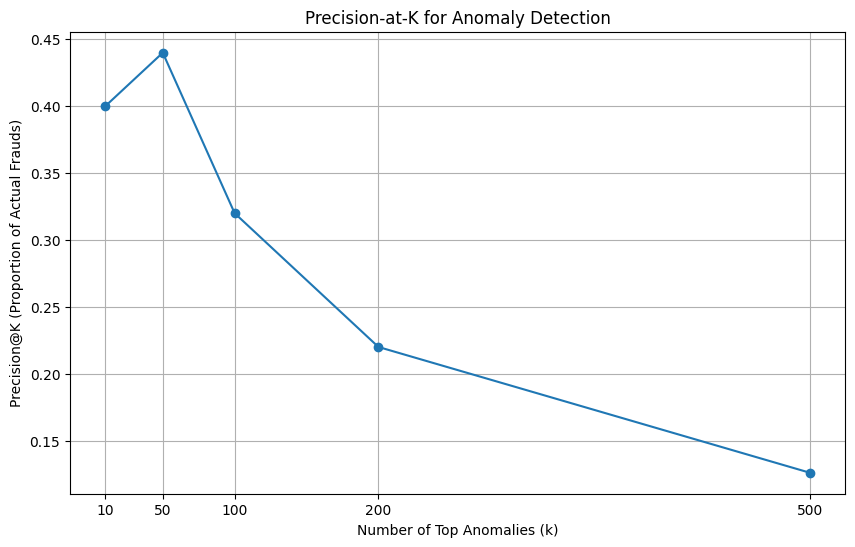

Precision-at-K values:
Precision@10: 0.4000
Precision@50: 0.4400
Precision@100: 0.3200
Precision@200: 0.2200
Precision@500: 0.1260


In [15]:
import matplotlib.pyplot as plt

# Step 3: Plot precision-at-k for k = 10, 50, 100, 200, 500
ks = [10, 50, 100, 200, 500]
precision_at_k_values = []

for k_val in ks:
    top_k_anomalies = sorted_df.head(k_val)
    actual_frauds_in_top_k = top_k_anomalies[top_k_anomalies['true_label'] == 1].shape[0]
    precision_at_k = actual_frauds_in_top_k / k_val if k_val > 0 else 0
    precision_at_k_values.append(precision_at_k)

plt.figure(figsize=(10, 6))
plt.plot(ks, precision_at_k_values, marker='o')
plt.title('Precision-at-K for Anomaly Detection')
plt.xlabel('Number of Top Anomalies (k)')
plt.ylabel('Precision@K (Proportion of Actual Frauds)')
plt.xticks(ks)
plt.grid(True)
plt.show()

print("Precision-at-K values:")
for i, k_val in enumerate(ks):
    print(f"Precision@{k_val}: {precision_at_k_values[i]:.4f}")


## Activity 4: Association Rule Mining

### Task 1 & 2: Manual Computation of Support, Confidence, and Lift

Below is the transaction table for your manual calculations. Please use this table to manually calculate support, confidence, and lift as per the instructions provided in your prompt. This will help you understand the underlying concepts before we verify them with code.

**Transaction Table:**

| Transaction ID | Items                   |
|----------------|-------------------------|
| T1             | Bread, Butter, Milk     |
| T2             | Bread, Butter           |
| T3             | Bread, Milk, Tea        |
| T4             | Butter, Milk, Tea       |
| T5             | Bread, Butter, Milk, Tea|
| T6             | Bread, Tea              |
| T7             | Milk, Tea               |
| T8             | Bread, Butter, Milk     |
| T9             | Bread, Milk             |
| T10            | Butter, Tea             |


### Task 3: Code Verification using `mlxtend`

Now, let's prepare the data for verification using the `mlxtend` library. The following code will create a DataFrame suitable for `mlxtend`'s `apriori` and `association_rules` functions.

In [18]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# Define the transaction data
transactions = [
    ['Bread', 'Butter', 'Milk'],
    ['Bread', 'Butter'],
    ['Bread', 'Milk', 'Tea'],
    ['Butter', 'Milk', 'Tea'],
    ['Bread', 'Butter', 'Milk', 'Tea'],
    ['Bread', 'Tea'],
    ['Milk', 'Tea'],
    ['Bread', 'Butter', 'Milk'],
    ['Bread', 'Milk'],
    ['Butter', 'Tea']
]

# Initialize TransactionEncoder
te = TransactionEncoder()

# Fit and transform the transactions
te_ary = te.fit(transactions).transform(transactions)
df_transactions = pd.DataFrame(te_ary, columns=te.columns_)

print("Encoded Transaction DataFrame:")
display(df_transactions.head())


Encoded Transaction DataFrame:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Bread,Butter,Milk,Tea
0,True,True,True,False
1,True,True,False,False
2,True,False,True,True
3,False,True,True,True
4,True,True,True,True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Next, we will apply the `apriori` algorithm to find frequent itemsets and then generate association rules. This will allow you to compare the results with your manual calculations.

In [19]:
from mlxtend.frequent_patterns import apriori, association_rules

# Apply the Apriori algorithm to find frequent itemsets with min_support=0.3
frequent_itemsets = apriori(df_transactions, min_support=0.3, use_colnames=True)

print("Frequent Itemsets (min_support=0.3):")
display(frequent_itemsets)

# Generate association rules with min_confidence=0.5
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

print("Association Rules (min_confidence=0.5):")
display(rules)


Frequent Itemsets (min_support=0.3):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
0,0.7,(Bread)
1,0.6,(Butter)
2,0.7,(Milk)
3,0.6,(Tea)
4,0.4,"(Butter, Bread)"
5,0.5,"(Milk, Bread)"
6,0.3,"(Tea, Bread)"
7,0.4,"(Butter, Milk)"
8,0.3,"(Butter, Tea)"
9,0.4,"(Milk, Tea)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Association Rules (min_confidence=0.5):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Butter),(Bread),0.6,0.7,0.4,0.666667,0.952381,1.0,-0.02,0.900000,-0.111111,0.444444,-0.111111,0.619048
1,(Bread),(Butter),0.7,0.6,0.4,0.571429,0.952381,1.0,-0.02,0.933333,-0.142857,0.444444,-0.071429,0.619048
2,(Milk),(Bread),0.7,0.7,0.5,0.714286,1.020408,1.0,0.01,1.050000,0.066667,0.555556,0.047619,0.714286
3,(Bread),(Milk),0.7,0.7,0.5,0.714286,1.020408,1.0,0.01,1.050000,0.066667,0.555556,0.047619,0.714286
4,(Tea),(Bread),0.6,0.7,0.3,0.500000,0.714286,1.0,-0.12,0.600000,-0.500000,0.300000,-0.666667,0.464286
5,(Butter),(Milk),0.6,0.7,0.4,0.666667,0.952381,1.0,-0.02,0.900000,-0.111111,0.444444,-0.111111,0.619048
6,(Milk),(Butter),0.7,0.6,0.4,0.571429,0.952381,1.0,-0.02,0.933333,-0.142857,0.444444,-0.071429,0.619048
7,(Butter),(Tea),0.6,0.6,0.3,0.500000,0.833333,1.0,-0.06,0.800000,-0.333333,0.333333,-0.250000,0.500000
8,(Tea),(Butter),0.6,0.6,0.3,0.500000,0.833333,1.0,-0.06,0.800000,-0.333333,0.333333,-0.250000,0.500000
9,(Milk),(Tea),0.7,0.6,0.4,0.571429,0.952381,1.0,-0.02,0.933333,-0.142857,0.444444,-0.071429,0.619048


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Task 4: Telecom Analogy

**What to do:** Map the identified items from the association rules to Uztelecom services. Based on the strongest rules (high lift, confidence, and support), write 2-3 business recommendations for Uztelecom. Think about how these product associations could translate into cross-selling, up-selling, or bundling strategies for telecom services.

**Tips:**
*   Consider the 'items' (Bread, Butter, Milk, Tea) as different Uztelecom services or products (e.g., 'Bread' could be 'Internet Package', 'Milk' could be 'Mobile Plan', 'Tea' could be 'TV Subscription', 'Butter' could be 'Value-Added Service like Cloud Storage').
*   Focus on rules with high lift, as lift > 1 indicates a strong positive association between items.
*   Your recommendations should be actionable and specific to Uztelecom's business model.